Dataset Shape:
(283726, 31)

First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.

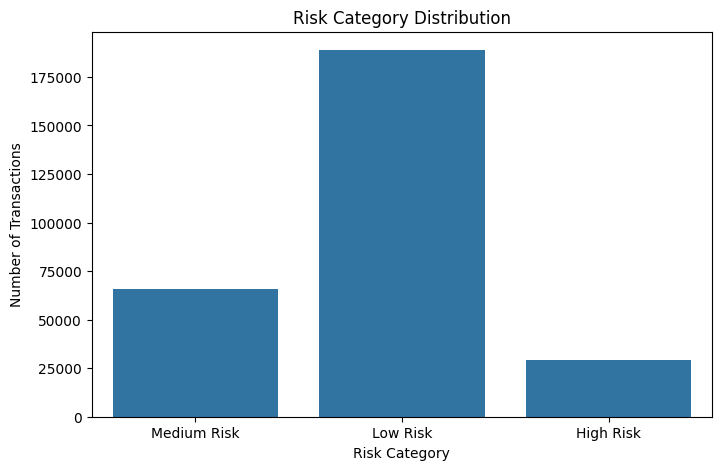


Fraud Distribution by Risk Category:
Class               0    1
Risk_Category             
High Risk       29166   82
Low Risk       188518  292
Medium Risk     65569   99


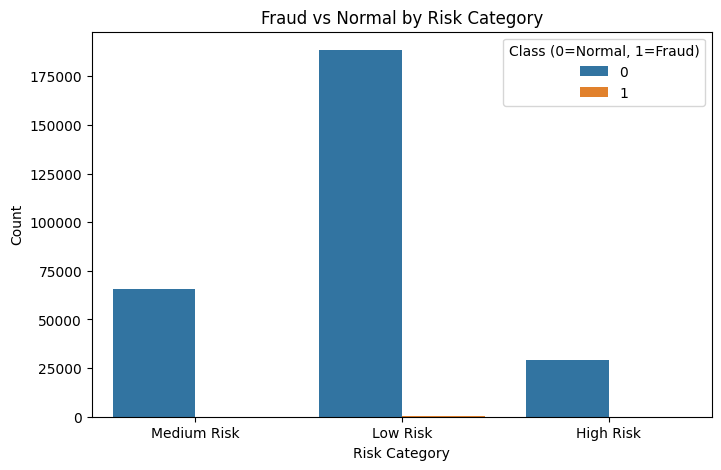


Total Fraud Amount by Risk Category:
Risk_Category
High Risk      45884.66
Medium Risk    10767.60
Low Risk        1939.13
Name: Amount, dtype: float64


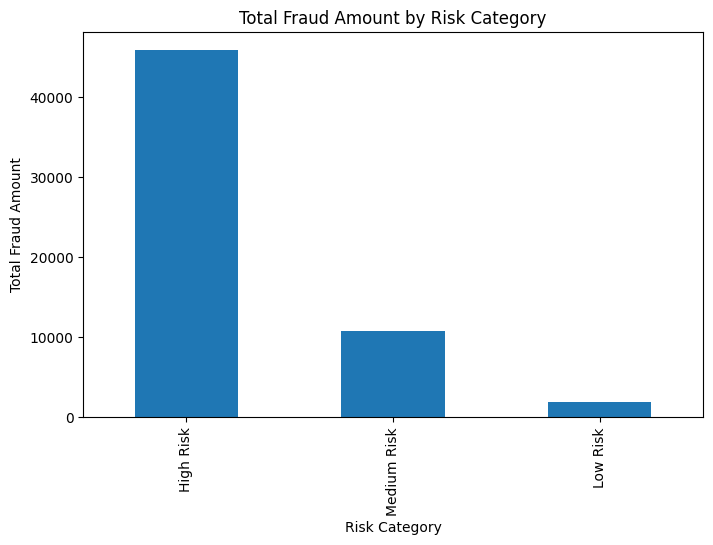


Average Fraud Amount by Risk Category:
Risk_Category
High Risk      559.569024
Medium Risk    108.763636
Low Risk         6.640856
Name: Amount, dtype: float64

Top 10 Highest Fraud Transactions:
            Time   Amount Risk_Category
175384  122608.0  2125.87     High Risk
6932      9064.0  1809.68     High Risk
248250  154278.0  1504.93     High Risk
88869    62467.0  1402.16     High Risk
81304    59011.0  1389.56     High Risk
95238    65385.0  1354.25     High Risk
199180  133184.0  1335.00     High Risk
10648    18088.0  1218.89     High Risk
248322  154309.0  1096.99     High Risk
232390  147501.0   996.27     High Risk

EXECUTIVE RISK KPI SUMMARY
Total Transactions: 283726
Fraud Transactions: 473
Fraud Percentage: 0.1667%
Total Fraud Loss: 58591.39
Average Fraud Amount: 123.87
High Risk Fraud Transactions: 82

BUSINESS RECOMMENDATIONS

1. Monitor repeated small-value transactions,
   not only high-value payments.

2. High-risk transactions (> 200 amount)
   should trigger imm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Load Cleaned Dataset
# --------------------------------------------------

df = pd.read_csv("../data/processed/creditcard_cleaned.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# --------------------------------------------------
# Step 1: Create Risk Categories
# --------------------------------------------------

def risk_category(amount):
    if amount < 50:
        return "Low Risk"
    elif amount < 200:
        return "Medium Risk"
    else:
        return "High Risk"

df["Risk_Category"] = df["Amount"].apply(risk_category)

print("\nRisk Category Created Successfully")
print(df[["Amount", "Risk_Category"]].head())

# --------------------------------------------------
# Step 2: Risk Category Distribution
# --------------------------------------------------

print("\nRisk Category Distribution:")
print(df["Risk_Category"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x="Risk_Category", data=df)

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Transactions")

plt.show()

# --------------------------------------------------
# Step 3: Fraud Distribution by Risk Category
# --------------------------------------------------

print("\nFraud Distribution by Risk Category:")
print(
    pd.crosstab(
        df["Risk_Category"],
        df["Class"]
    )
)

plt.figure(figsize=(8, 5))
sns.countplot(
    x="Risk_Category",
    hue="Class",
    data=df
)

plt.title("Fraud vs Normal by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.legend(title="Class (0=Normal, 1=Fraud)")

plt.show()

# --------------------------------------------------
# Step 4: Total Fraud Amount by Risk Category
# --------------------------------------------------

fraud_df = df[df["Class"] == 1]

print("\nTotal Fraud Amount by Risk Category:")
print(
    fraud_df.groupby("Risk_Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

fraud_df.groupby("Risk_Category")["Amount"] \
    .sum() \
    .sort_values(ascending=False) \
    .plot(
        kind="bar",
        figsize=(8, 5)
    )

plt.title("Total Fraud Amount by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Total Fraud Amount")

plt.show()

# --------------------------------------------------
# Step 5: Average Fraud Amount by Risk Category
# --------------------------------------------------

print("\nAverage Fraud Amount by Risk Category:")
print(
    fraud_df.groupby("Risk_Category")["Amount"]
    .mean()
    .sort_values(ascending=False)
)

# --------------------------------------------------
# Step 6: Top 10 Highest Fraud Transactions
# --------------------------------------------------

top_fraud = fraud_df.sort_values(
    by="Amount",
    ascending=False
).head(10)

print("\nTop 10 Highest Fraud Transactions:")
print(
    top_fraud[
        ["Time", "Amount", "Risk_Category"]
    ]
)

# --------------------------------------------------
# Step 7: Executive Risk KPI Summary
# --------------------------------------------------

total_transactions = len(df)
fraud_transactions = df["Class"].sum()
fraud_percentage = (
    fraud_transactions / total_transactions
) * 100

total_fraud_loss = fraud_df["Amount"].sum()
avg_fraud_amount = fraud_df["Amount"].mean()

high_risk_fraud_count = len(
    fraud_df[
        fraud_df["Risk_Category"] == "High Risk"
    ]
)

print("\n===================================")
print("EXECUTIVE RISK KPI SUMMARY")
print("===================================")

print(f"Total Transactions: {total_transactions}")
print(f"Fraud Transactions: {fraud_transactions}")
print(f"Fraud Percentage: {round(fraud_percentage, 4)}%")
print(f"Total Fraud Loss: {round(total_fraud_loss, 2)}")
print(f"Average Fraud Amount: {round(avg_fraud_amount, 2)}")
print(f"High Risk Fraud Transactions: {high_risk_fraud_count}")

# --------------------------------------------------
# Step 8: Business Recommendations
# --------------------------------------------------

print("\n===================================")
print("BUSINESS RECOMMENDATIONS")
print("===================================")

print("""
1. Monitor repeated small-value transactions,
   not only high-value payments.

2. High-risk transactions (> 200 amount)
   should trigger immediate fraud alerts.

3. Behavioral features like V14, V17, V12
   should be prioritized over simple amount checks.

4. Real-time anomaly detection systems
   should be implemented for stronger fraud prevention.

5. Manual fraud review teams should focus
   on Medium + High Risk categories first.
""")